<a href="https://colab.research.google.com/github/Yashaswini944/Sentiment-analysis-for-social-media/blob/main/Sentiment_analysis_for_social_media.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classification Report:

              precision    recall  f1-score   support

    Negative       0.33      1.00      0.50         1
     Neutral       0.00      0.00      0.00         1
    Positive       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.11      0.33      0.17         3
weighted avg       0.11      0.33      0.17         3



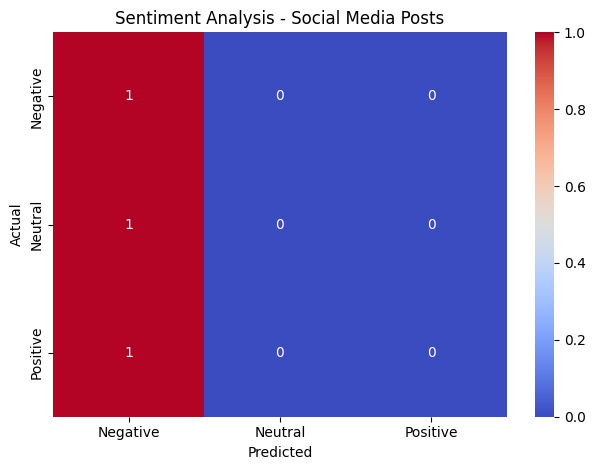

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Simulated social media dataset
data = {
    'Post': [
        "I love the new features on this app! So smooth!",
        "Worst update ever. Totally ruined the experience.",
        "The design looks cool but it's a bit slow.",
        "Absolutely fantastic support team!",
        "I'm not happy with the recent bugs.",
        "Great job on the new dashboard layout!",
        "It crashes every time I open it!",
        "Neutral about the update, nothing special.",
        "This app has really improved over time.",
        "Still waiting on a fix for this issue..."
    ],
    'Sentiment': [
        'Positive', 'Negative', 'Neutral', 'Positive', 'Negative',
        'Positive', 'Negative', 'Neutral', 'Positive', 'Negative'
    ]
}

df = pd.DataFrame(data)

# Encode labels
df['Sentiment_Label'] = df['Sentiment'].astype('category').cat.codes
label_map = dict(enumerate(df['Sentiment'].astype('category').cat.categories))

# Text vectorization
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['Post'])
y = df['Sentiment_Label']

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train logistic regression classifier
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1, 2],  # Ensure all classes are included
    target_names=label_map.values(),
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='coolwarm',
    xticklabels=label_map.values(),
    yticklabels=label_map.values()
)

plt.title("Sentiment Analysis - Social Media Posts")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
